## Physical BVD experiments: do not run, outdated methods

In [15]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager_reinoud import Bridge

import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Initiation: load beam library, select beams for experiment and set parameters.
library_name = 'BVD4'
library = open_beam_library(library_name + '.json')
selection = ['A1']
lib = sublibrary(selection, library)

R_ref = 10 # Ohm
U_in = 10 # V

# f_arr = np.logspace(2, 5, 1000)
# w_arr = 2*np.pi*f_arr

def make_adaptive_w(library, n_coarse=200, n_fine=150, bw_factor=5):
    f_coarse = np.logspace(2, 5, n_coarse)
    f_fine_list = [f_coarse]
    for beam in library.values():
        w0 = 1 / np.sqrt(beam.L * beam.C)
        f0 = w0 / (2 * np.pi)
        Q = w0 * beam.L / beam.R_0
        bw = f0 / Q
        f_fine = np.linspace(f0 - bw_factor * bw/2,
                             f0 + bw_factor * bw/2, n_fine)
        f_fine_list.append(f_fine[f_fine > 0])
    f_combined = np.unique(np.concatenate(f_fine_list))
    return 2 * np.pi * f_combined

# A triangle with A in the floor, B inclined at the left and a C at the right:
topology = [(0, 1)]
struc = Bridge()
struc.construct(lib, topology)

w_arr = struc.make_adaptive_w(
    n_coarse=200,
    n_fine=150,
    bw_factors=[5, 5, 50]   # per beam: A1, B1, C1
)
f_arr = w_arr / (2 * np.pi)   # voor de plots
# Solve for bridge frequency response, but let the solver add noise to U_out:


Exception: bw_factors length 3 does not match number of beams 1

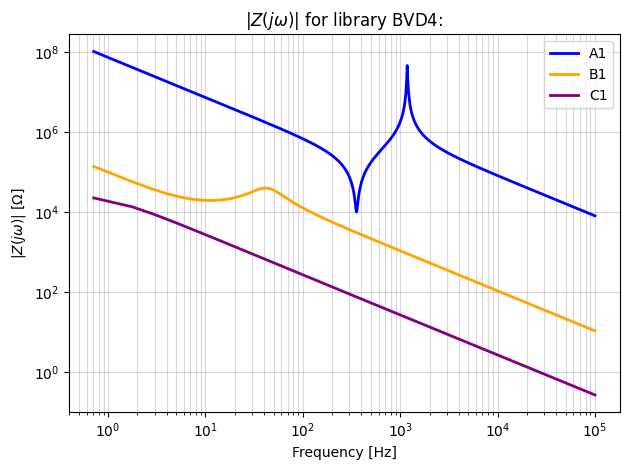

In [ ]:
fig, ax = plt.subplots()
colors = ['blue', 'orange', 'purple']

for key, color in zip(list(lib.keys()), colors):
    
    y = lib[key].admittance(w_arr)
    z_abs = 1 / np.abs(y)

    ax.loglog(f_arr, z_abs, color=color, label=key, linewidth=2)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()
plt.show()



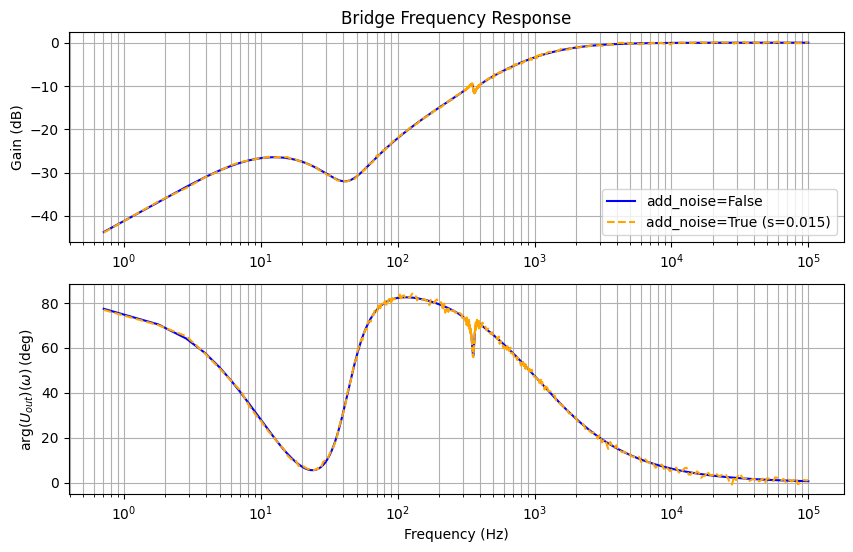

In [ ]:


# Initialize RNG:
rng = np.random.default_rng(seed=42)
sigma = 0.01

# Run simulation with and without noise:
U_arr = np.array([struc.solve_U(w, U_in, R_ref, add_noise = False) for w in w_arr]).T
U_out_arr = U_arr[-1,:]
U_mag = np.abs(U_out_arr)
U_phase = np.angle(U_out_arr)

U_arr_noise = np.array([struc.solve_U(w, U_in, R_ref, add_noise = True, sigma=sigma, rng=rng) for w in w_arr]).T
U_out_arr_noise = U_arr_noise[-1,:]
U_mag_noise = np.abs(U_out_arr_noise)
U_phase_noise = np.angle(U_out_arr_noise)

# Plotting:
plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, 20*np.log10(U_mag/U_in), color='blue', label = 'add_noise=False')
plt.semilogx(f_arr, 20*np.log10(U_mag_noise/U_in), color='orange', linestyle='--', label = f'add_noise=True (s={sigma})')
plt.ylabel('Gain (dB)')
plt.grid(True, which="both")
plt.legend(loc = 'lower right')
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_phase), color='blue', label = 'add_noise=False')
plt.semilogx(f_arr, np.degrees(U_phase_noise), color='orange', linestyle='--', label = f'add_noise=True (s={sigma})')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

[ 9698.66005519 25550.56787359 42297.85659465]


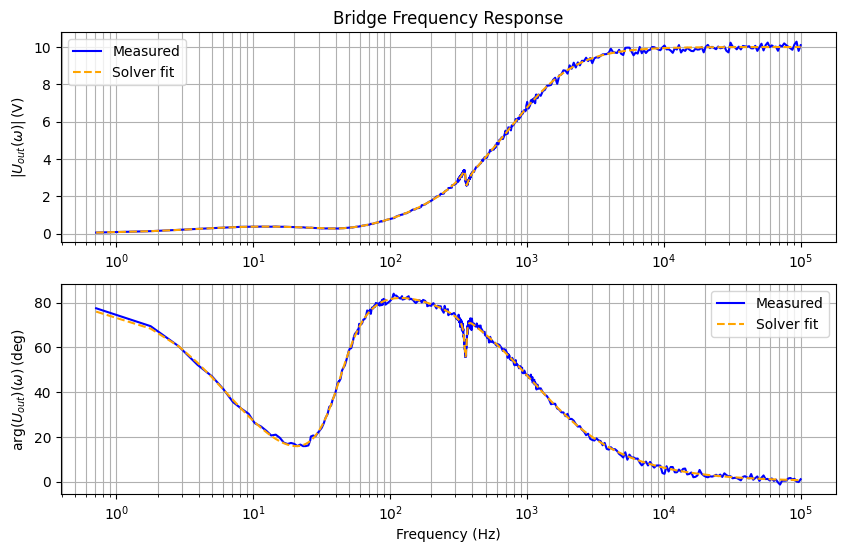

In [ ]:
# Recover R values for deformed triangle WITHOUT noise:

# Let's pretend no deformation in A, but elongation in both B and C:
R_deformed = [10000.0, 25500.0, 35000.0] # 50 Ohm R_0 for all beams in BVD1.json

# The measured response (with noise!) should equal:
U_arr_mes = np.array([struc.solve_U(w, U_in, R_ref, R_vec=R_deformed, 
                                    add_noise = True, sigma=sigma, rng=rng) for w in w_arr]).T
U_out_mes = U_arr_mes[-1,:]

# Let's see what resistances the solver predicts:
R_pred = struc.predict_R(w_arr, U_in, U_out_mes, R_ref)
print(R_pred)
# Plotting:
U_out_mag_mes = np.abs(U_out_mes)
U_out_phase_mes = np.angle(U_out_mes)

U_arr_pred = np.array([struc.solve_U(w, U_in, R_ref, R_vec=R_pred) for w in w_arr]).T
U_out_pred = U_arr_pred[-1,:]
U_out_mag_pred = np.abs(U_out_pred)
U_out_phase_pred = np.angle(U_out_pred)

plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_out_mag_mes, color='blue', label = 'Measured')
plt.semilogx(f_arr, U_out_mag_pred, color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.legend()
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_out_phase_mes), color='blue', label = 'Measured')
plt.semilogx(f_arr, np.degrees(U_out_phase_pred), color='orange', linestyle='--', label = f'Solver fit')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")
plt.legend()